#### Network traffic

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

import keras
import tensorflow as tf

In [2]:
tf.random.set_seed(42)

In [3]:
# Zadanie 1

df = pd.read_csv('kddcup.data_10_percent.gz')

def extract_col_names(cols_with_descriptions: list[str]) -> list[str]:
    """
    Cleans features names from .names file.
    List of features are saved as string with format: 'num_file_creations: continuous.' -> Function cleans this splitting each str on colon and returning
    named features list.
    """
    col_names = []
    for col in cols_with_descriptions:
        col_name = col.split(":")[0]
        col_names.append(col_name)
    return col_names

def clean_labels_name(labels: list[str]) -> list[str]:
    """
    After reading .names files some class labels can be malformed with new line char -> clean all string just in case
    """
    return list(map(lambda x: x.replace(".\n", ""), labels))


with open("kddcup.names") as f:
    content = f.readlines()
    class_labels = content[0].split(",")
    feature_names = content[1:]

    labels = clean_labels_name(class_labels)  # First element of array are class labels - retrive them and clean strings for unified format
    headers = extract_col_names(feature_names)  # Remove class labels, get rest of col names into separated array - clean strings

# Prepare headers for dataframe, one missing col is for class labels
headers.append('outcome')
df.columns = headers

# assert dataframe preparation went well
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  str    
 2   service                      494020 non-null  str    
 3   flag                         494020 non-null  str    
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   land                         494020 non-null  int64  
 7   wrong_fragment               494020 non-null  int64  
 8   urgent                       494020 non-null  int64  
 9   hot                          494020 non-null  int64  
 10  num_failed_logins            494020 non-null  int64  
 11  logged_in                    494020 non-null  int64  
 12  num_compromised              494020 non-null  int64  
 13  root_shell

In [4]:
# Zadnaie 2
# EDA 

df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494020.000000,4.940200e+05,4.940200e+05,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,...,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000
mean,47.979400,3.025616e+03,8.685232e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148245,0.010212,...,232.471230,188.666034,0.753779,0.030906,0.601936,0.006684,0.176754,0.176443,0.058118,0.057412
std,707.747185,9.882191e+05,3.304003e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355343,1.798328,...,64.744665,106.040236,0.410781,0.109259,0.481309,0.042133,0.380593,0.380920,0.230590,0.230141
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='count', ylabel='outcome'>

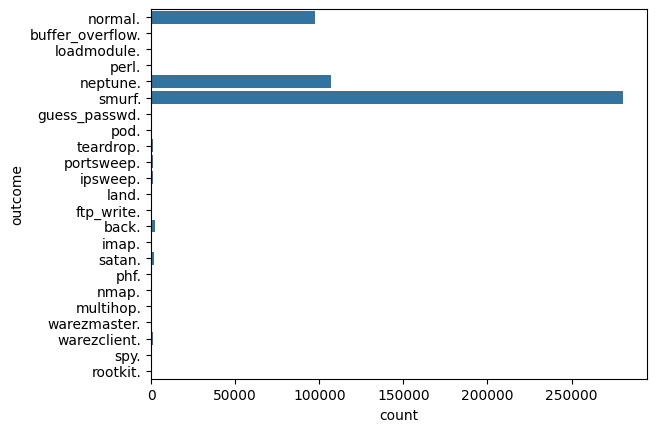

In [5]:
sns.countplot(df["outcome"])

# Almost half of dataset records are classified as smurfing, Around ~20-25% is neptune, and ~20% is normal outcome

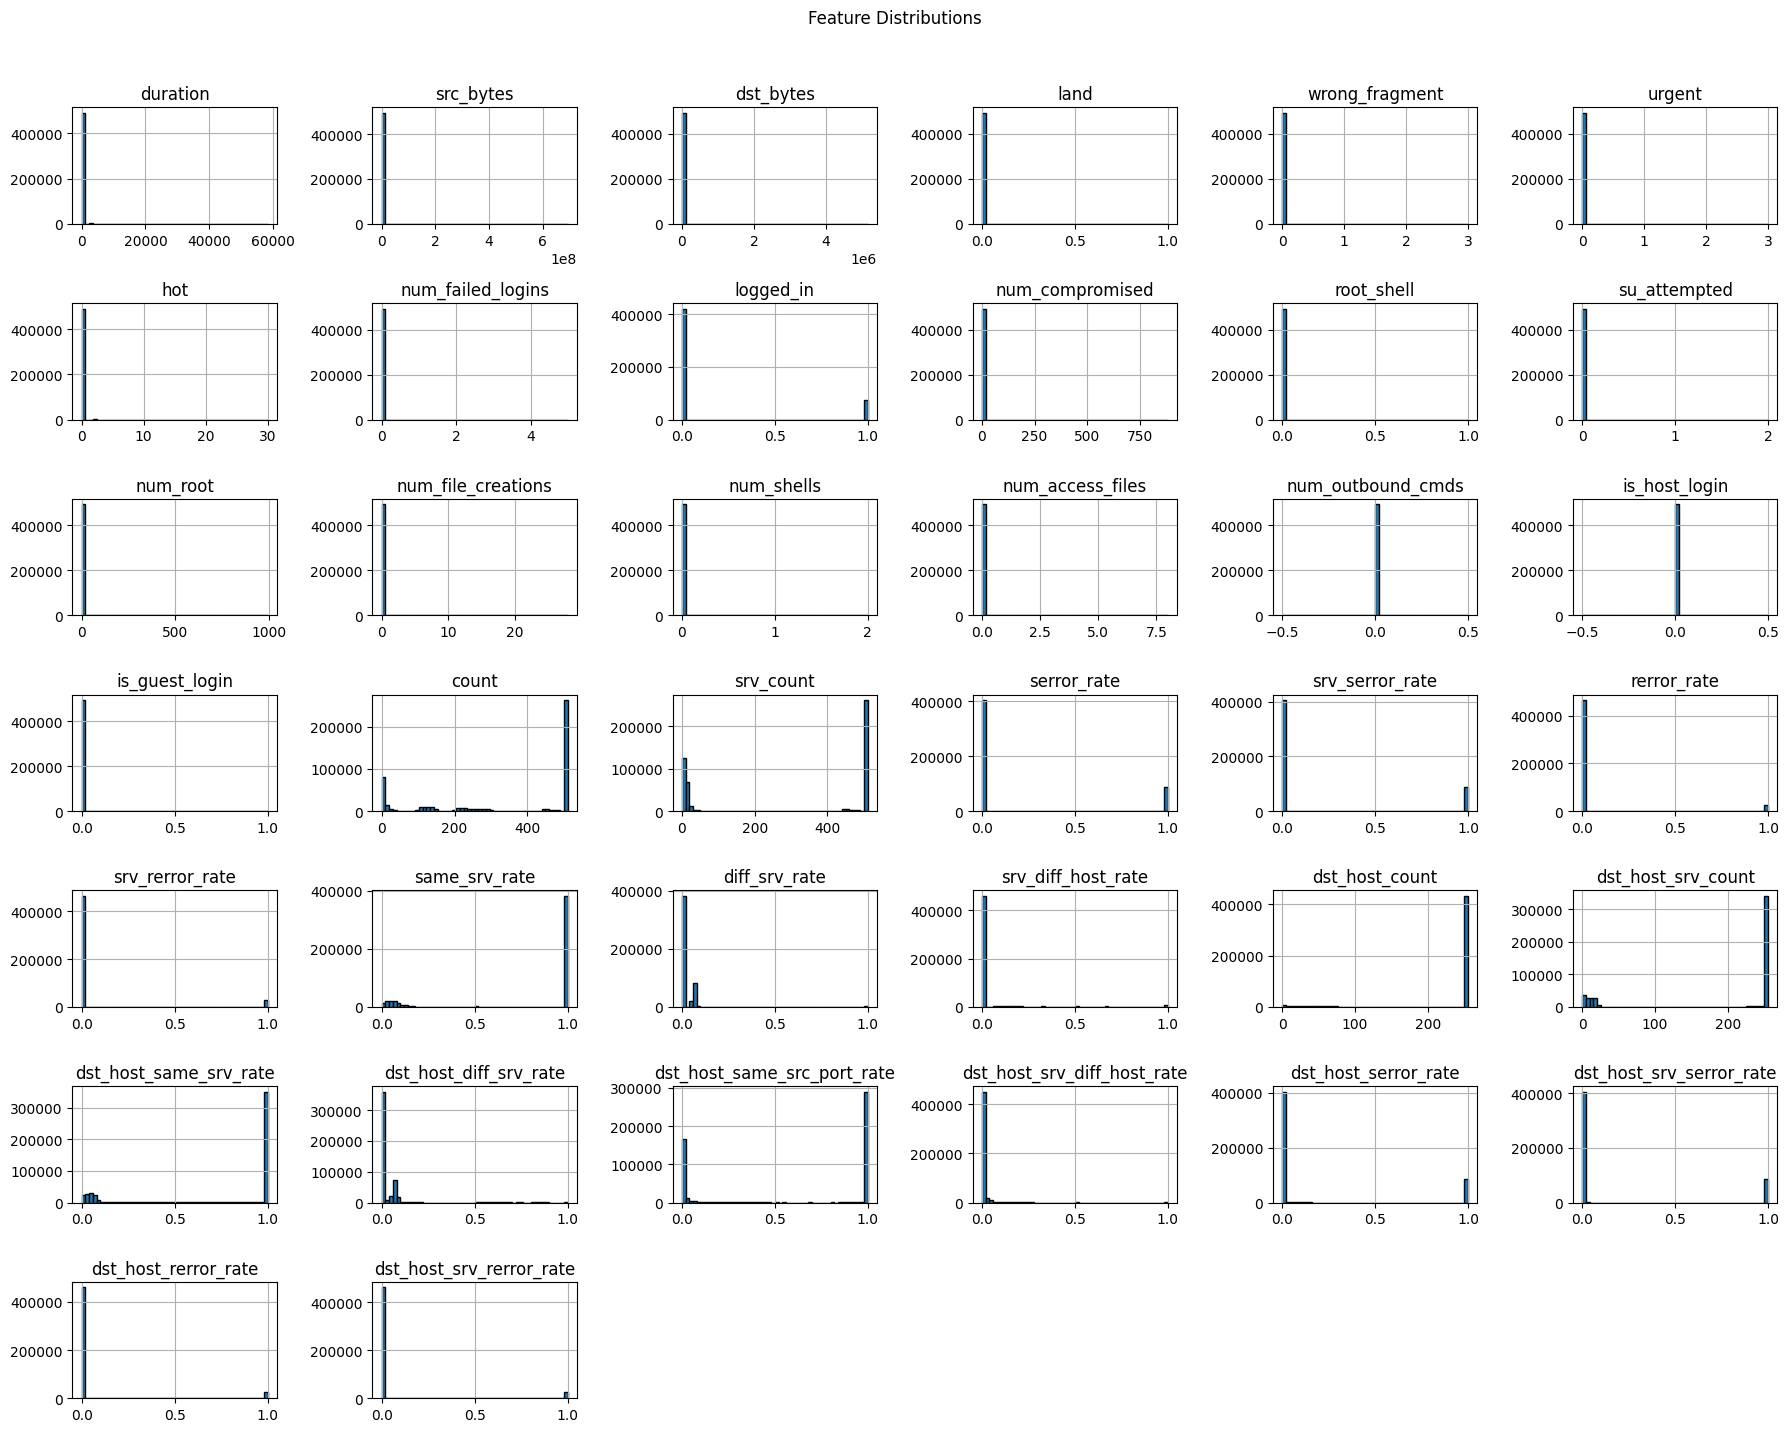

In [6]:
df.hist(figsize=(18, 14), bins=50, edgecolor='black')
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

#### Histplot and data distribution

What can be seen at the very fist glance is the fact that features are heavily skewed towards one option. This can be problematic - we can see that binary features have very uneven distribution meaning one option is domination heavy very often. 

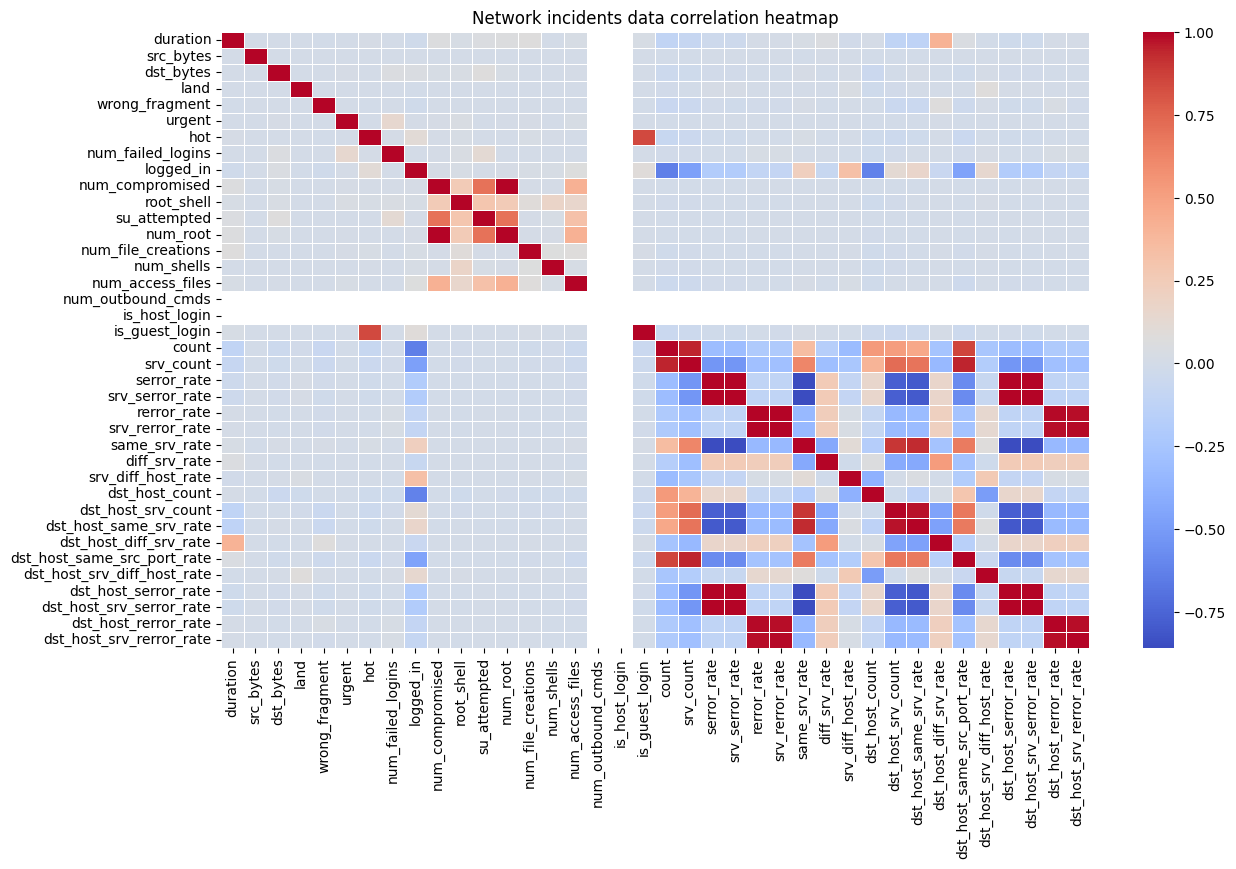

In [7]:
df_num = df.select_dtypes("number")
corr_matrix = df_num.corr(method="pearson")

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Network incidents data correlation heatmap")
plt.show()

#### Corr matrix summary

Observing the correlation matrix we can find high correlation clusters of data. 
For example, in the upper left corner features like root_shell, num_compromised and num_root form such a cluster.
We benefit from these clusters due to the fact that during autoencoder training we can identify data redundancy — some features are heavily dependent on each other. This dependency is learnt by the model during training via backpropagation — if one of the clustered features goes up, the other ones from the high-correlation group go up too. Because of that we can narrow the bottleneck of our model architecture — the autoencoder will reconstruct the data output based on the learned behavior of features from high-correlation clusters.

In [8]:
# Zadanie 3

# Check null values - 0 in each feature
null_values = df.isna().sum()
null_values

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [9]:
df.select_dtypes("str")  # excluding label colum (outcome), dataset contains 3 categorical features

,protocol_type,service,flag,outcome
0,tcp,http,SF,normal.
1,tcp,http,SF,normal.
2,tcp,http,SF,normal.
3,tcp,http,SF,normal.
4,tcp,http,SF,normal.
...,...,...,...,...
494015,tcp,http,SF,normal.
494016,tcp,http,SF,normal.
494017,tcp,http,SF,normal.
494018,tcp,http,SF,normal.


<Axes: xlabel='count', ylabel='protocol_type'>

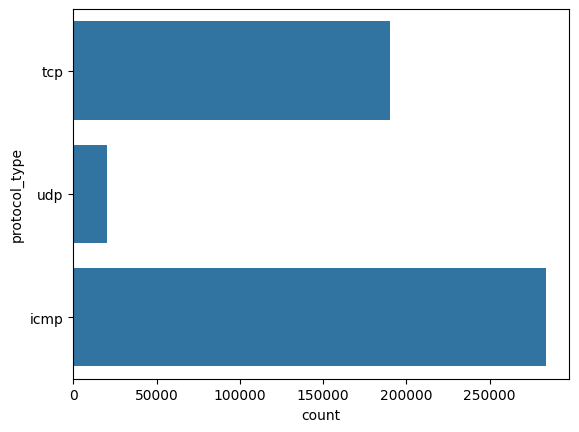

In [10]:
# 3 values total, where icmp is the dominant, feature can be encoded with one-hot encoder
sns.countplot(df["protocol_type"])

Display counts of each flag value: 
 flag
SF        378439
S0         87007
REJ        26875
RSTR         903
RSTO         579
SH           107
S1            57
S2            24
RSTOS0        11
S3            10
OTH            8
Name: count, dtype: int64


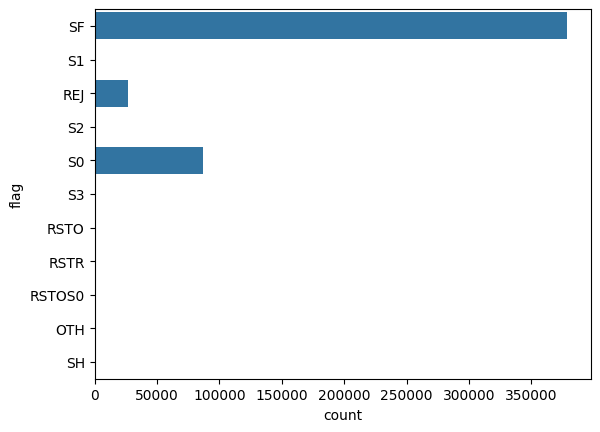

In [11]:
# Flag - Dominant (SF), with two other values REJ and S0 being the noticeably occuring
# We can combine other records into common label - "Other", as 4th value "RSTR" occurs 903 time in dataset,
# in comparsion to 3rd "REJ" (almost 27k occurences). The rest flags are even rarer so grouping them to
# 3 majors flags and category "Other" can make sense his to avoid inflating the dataset with encoded values.
sns.countplot(df["flag"])

print("Display counts of each flag value: \n", df["flag"].value_counts())

In [12]:
major_flags = ["SF", "S0", "REJ"]

# Aggregate all other categories of flag feature into common "Other"
df['flag'] = df['flag'].where(df['flag'].isin(major_flags), other='Other')

print("Show aggregated flags: \n", df["flag"].value_counts())

Show aggregated flags: 
 flag
SF       378439
S0        87007
REJ       26875
Other      1699
Name: count, dtype: int64


In [13]:
counts = df["service"].value_counts()

print(counts) # 66 unique values with at least 1 record in df

# Category 'other' already exist with 7237 values, this int value is set as threshold to aggregate 
# everything below this
other_threshold = counts["other"] 

def convert_to_other(cat: str, value_counts: pd.Series, threshold: int):
    if value_counts[cat] < threshold:
            return "other"
    else: return cat


df["service"] = df["service"].map(lambda x: convert_to_other(x, counts, other_threshold))

df["service"].value_counts() # Other after aggregate - 27712 records


service
ecr_i      281400
private    110893
http        64292
smtp         9723
other        7237
            ...  
X11            11
tim_i           7
pm_dump         1
tftp_u          1
red_i           1
Name: count, Length: 66, dtype: int64


service
ecr_i      281400
private    110893
http        64292
other       27712
smtp         9723
Name: count, dtype: int64

In [14]:
# Zadanie 4

# Split dataset with 8/2 ratio 
X_train, X_test = train_test_split(df, test_size=0.2)

# Separate normal and anomaly into separate sets
X_train_normal = X_train.loc[X_train["outcome"] == 'normal.']
X_train_anom = X_train.loc[X_train["outcome"] != 'normal.']

X_test_normal = X_test.loc[X_test["outcome"] == 'normal.']
X_test_anom = X_test.loc[X_test["outcome"] != 'normal.']

# Drop outcome col from splits
X_train_normal = X_train_normal.drop(["outcome"], axis=1)
X_train_anom = X_train_anom.drop(["outcome"], axis=1)

X_test_normal = X_test_normal.drop(["outcome"], axis=1)
X_test_anom = X_test_anom.drop(["outcome"], axis=1)

In [15]:
def one_hot_encode_cat_feature(encoder: OneHotEncoder, feature_name: str, df: pd.DataFrame) -> pd.DataFrame:
    """
    Uses one hot encoding for specified categorical feature in dataframe.
    Args:
    encoder: one hot encoder that is already fitted on training set data - here it only performs data
    transformation.
    feature_name: str - column name that should be be one hot encoded.
    df: pd.Dataframe - dataframe to perform operation on.

    Returns:
    Mutated dataframe with updated indexes, dropped original column and merged new one-hot encoded columns.
    """
    # Encode feature into one hot with dropping first column strategy
    feature_encoded = encoder.transform(df[[feature_name]])
    feature_encoded_df = pd.DataFrame(feature_encoded, columns=encoder.get_feature_names_out())

    # Merge new encoded cols and drop original one
    df = df.drop(labels=[feature_name], axis=1)
    df = df.reset_index(drop=True)
    return pd.concat([df, feature_encoded_df], axis=1)

In [16]:
# Use one hot encoding for each categorical column
one_hot_encode_cols = ["protocol_type", "flag", "service"]

for col in one_hot_encode_cols:
    one_hot_encoder = OneHotEncoder(drop="first", sparse_output=False)
    one_hot_encoder.fit(X_train[[col]])
    X_train_normal = one_hot_encode_cat_feature(encoder=one_hot_encoder, feature_name=col, df=X_train_normal)
    X_train_anom = one_hot_encode_cat_feature(encoder=one_hot_encoder, feature_name=col, df=X_train_anom)

    X_test_normal = one_hot_encode_cat_feature(encoder=one_hot_encoder, feature_name=col, df=X_test_normal)
    X_test_anom = one_hot_encode_cat_feature(encoder=one_hot_encoder, feature_name=col, df=X_test_anom)

In [ ]:
scaler = MinMaxScaler()

X_train_combined = np.concatenate([X_train_normal, X_train_anom])

scaler.fit(X_train_combined)

X_train_normal = scaler.transform(X_train_normal)
X_train_anom = scaler.transform(X_train_anom)

X_test_normal = scaler.transform(X_test_normal)
X_test_anom = scaler.transform(X_test_anom)

/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/Users/jancewicz/Repos/PJATK/PJATK---Artificial-Intelligence-Postgraduate-Studies-/keras/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without

In [44]:
len(X_train_combined)

395216

In [18]:
# Zadanie 5

# Each set has the same shape (47 features) we can make variable from train set of general shape
shape = X_train_normal.shape[1:]

# Encoder
input = keras.layers.Input(shape=shape, name="Input")
enc_first = keras.layers.Dense(128, activation="relu", name="Encoder_first")(input)
enc_second = keras.layers.Dense(32, activation="relu", name="Encoder_second")(enc_first)
enc_third = keras.layers.Dense(8, activation="relu", name="Encoder_third")(enc_second)

encoder = keras.Model(input, enc_third, name="Encoder")
encoder.summary()

# Decoder
dec_input = keras.layers.Input(shape=(8,), name="Decoder_input")
dec_first = keras.layers.Dense(8, activation="relu", name="Decoder_first")(dec_input)

dec_second = keras.layers.Dense(32, activation="relu", name="Decoder_second")(dec_first)
dec_third = keras.layers.Dense(128, activation="relu", name="Decoder_third")(dec_second)
dec_fourth = keras.layers.Dense(X_train_normal.shape[1], activation="sigmoid", name="Decoder_fourth")(dec_third)

output = keras.layers.Reshape(shape, name="Output")(dec_fourth)

decoder = keras.Model(dec_input, output, name="Decoder")
decoder.summary()


2026-06-04 14:47:39.778358: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-06-04 14:47:39.778427: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-04 14:47:39.778434: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1780552059.778444 1970124 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780552059.778462 1970124 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 47)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_first (Dense)           │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_second (Dense)          │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_third (Dense)           │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,536 (41.16 KB)

 Trainable params: 10,536 (41.16 KB)

...

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Decoder_input (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_first (Dense)           │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_second (Dense)          │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_third (Dense)           │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_fourth (Dense)          │ (None, 47)             │         6,063 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Reshape)                │ (None, 47)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,647 (41.59 KB)

 Trainable params: 10,647 (41.59 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
autoencoder = keras.Model(input, decoder(encoder(input)), name='Autoencoder')

lr = 1e-5
opt = keras.optimizers.RMSprop(learning_rate=lr)
autoencoder.compile(optimizer=opt, loss='binary_crossentropy')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 47)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 8)              │        10,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 47)             │        10,647 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,183 (82.75 KB)

 Trainable params: 21,183 (82.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Zadanie 6

# Start training
n_epochs = 100
batch_size = 256

# Fit only normal traffic training data, so model learns how to recreate it properly.
# Then compute recreation error to distinct anomalies from normal traffic based on specific threshold.
fit = autoencoder.fit(
    X_train_normal, X_train_normal, 
    epochs=n_epochs, 
    batch_size=batch_size, 
    validation_data=(X_test_normal, X_test_normal),
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ]
)

Epoch 1/100


2026-06-04 14:47:40.130617: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6856 - val_loss: 0.6618
Epoch 2/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6386 - val_loss: 0.6145
Epoch 3/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5918 - val_loss: 0.5685
Epoch 4/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5474 - val_loss: 0.5259
Epoch 5/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5073 - val_loss: 0.4873
Epoch 6/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4688 - val_loss: 0.4483
Epoch 7/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4285 - val_loss: 0.4067
Epoch 8/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3863 - val_loss: 0.3632
Epoch 9/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3398 - val_loss: 0.3119
Epoch 10/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2875 - val_loss: 0.2623
Epoch 11/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2430 - val_loss: 0.2239
Epoch 12/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

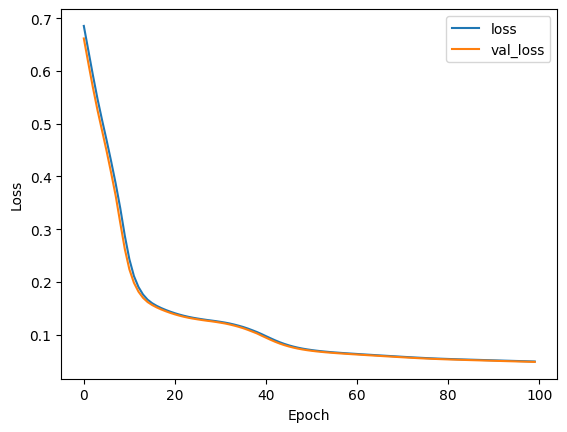

In [21]:
# Display training on the plot
plt.plot(fit.history['loss'], label='loss')
plt.plot(fit.history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# Zadanie 7

X_train_normal_decoded = autoencoder.predict(X_train_normal, batch_size=batch_size)
X_train_anom_decoded = autoencoder.predict(X_train_anom, batch_size=batch_size)

X_test_normal_decoded = autoencoder.predict(X_test_normal, batch_size=batch_size)
X_test_anom_decoded = autoencoder.predict(X_test_anom, batch_size=batch_size)

304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step


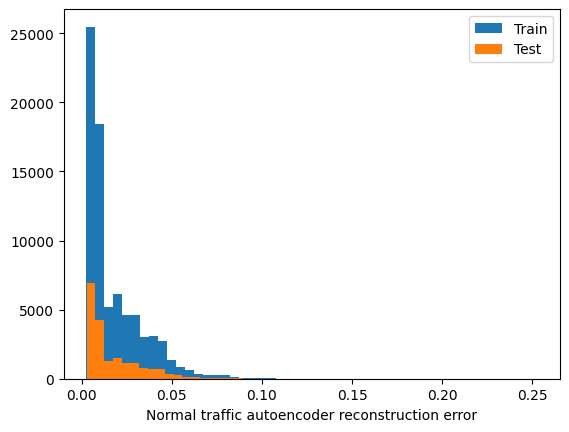

In [ ]:
train_normal_re = np.mean(np.abs(X_train_normal - X_train_normal_decoded), axis=1)
test_normal_re = np.mean(np.abs(X_test_normal - X_test_normal_decoded), axis=1)

train_anom_re = np.mean(np.abs(X_train_anom - X_train_anom_decoded), axis=1)
test_anom_re = np.mean(np.abs(X_test_anom - X_test_anom_decoded), axis=1)

plt.hist(train_normal_re, bins=50, label='Train')
plt.hist(test_normal_re, bins=50, label='Test')
plt.xlabel('Normal traffic autoencoder reconstruction error')
plt.legend()
plt.show()

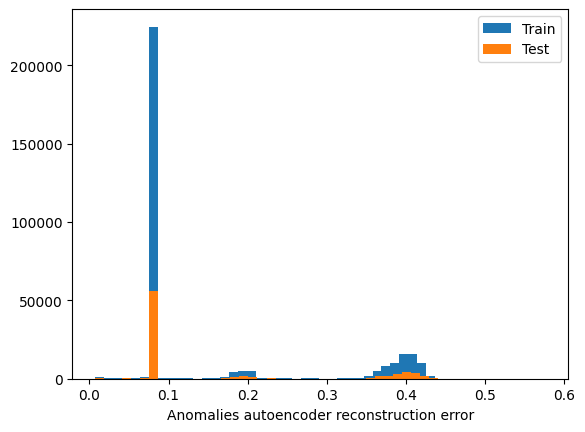

In [24]:


plt.hist(train_anom_re, bins=50, label='Train')
plt.hist(test_anom_re, bins=50, label='Test')
plt.xlabel('Anomalies autoencoder reconstruction error')
plt.legend()
plt.show()

In [42]:

# Looking at the plot of anomalies, we observe huge cluster of abnormal traffic that starts around 0.1 
# This is a good point to set a threshold value for the model.

THRESHOLD = 0.07

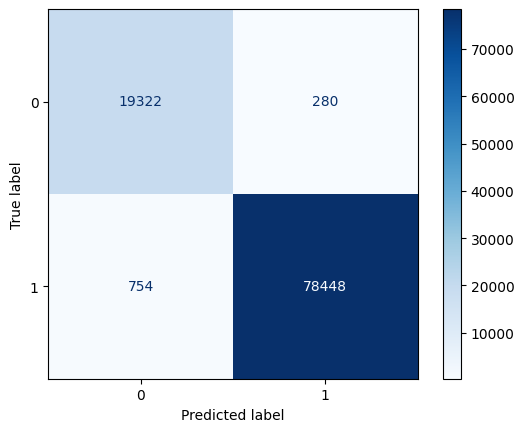

In [43]:
# Create array where each element is int 0 representing normal traffic. 
# Length of the array is the same as test set of normal traffic, representing labels
true_labels_normal = [
    0 for _ in X_test_normal
]
# Do the same for detecred anomalies - each anomaly is represented as label 1
true_labels_anom = [
    1 for _ in X_test_anom
]

# Merge them into one common array of true labels (0 - normal, 1 - anom)
true_labels = true_labels_normal + true_labels_anom

assert len(test_normal_re) == len(true_labels_normal)
assert len(test_anom_re) == len(true_labels_anom)

# Merge reconstruction error of normal traffic from encoder predictions array and anomalies array
# This allows to compare actual true labels with model predictions - recreation errors
preds_re = np.concatenate([test_normal_re, test_anom_re])

pred_labels = [
    0 if THRESHOLD > pred_re else 1 for pred_re in preds_re 
]

cm_preds_network = confusion_matrix(y_true=true_labels, y_pred=pred_labels)
disp_train_cm = ConfusionMatrixDisplay(cm_preds_network)
disp_train_cm.plot(cmap="Blues")

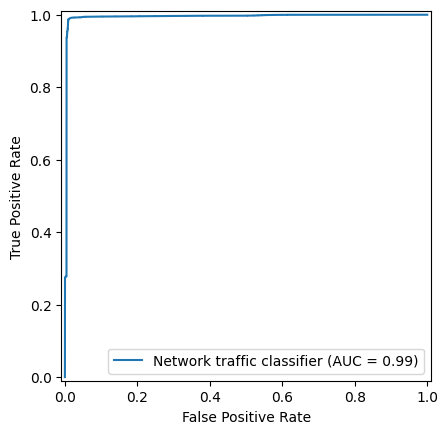

In [41]:
fpr, tpr, thresholds = roc_curve(true_labels, preds_re)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name="Network traffic classifier").plot()

Such ROC curves tells that on randomly selected record that is an attack, there is 99% probability it will have higher reconstruction error than the normal traffic, which is the indicator of anomaly detection.

#### Discussion

Acquired ROC curve and auc score (0.99) can be interpreted as very good outcome. Score means that for randomly chosen sample if the sample will be an anomaly there is probability of 99% that recreation error will have higher value than for sampel of standard, not malformed traffic.

Based on confusion matrix outcomes and TP, TN, FP, FN ratio, the 0.07 threshold value provides the best outcome for the model. It slightly increase False positives which is acceptable for this task, while reducing amount of false negative (attack classified as normal) in comparsion to 0.08 or 0.1 value that had much worse outcomes, meaning models with such threshold had multiple time (up to 57k records) of false negatives. With such model (classifier of network attacks) there is no room for such high mistake.

In general, autoencoder can overfit, but with chosen architecture of the model:
> Encoder Input (47 1d tensor)
> Encoder First layer 128 cells
> Encoder Second layer 32 
> Encoder Representation layer 8
> Decoder First layer 32
> Decoder second layer 128
> Output

Having simple model combined with relatively big training set (77675 records of X_train_normal) creates a good environment for learning general patterns of the data without possibility to memorize whole dataset. With such ratio of model size to training set model does not overfits and can recreate non-malformed network traffic with great result. The dropout layers were unnecessary for this project because that simple architecture had great outcomes.


I decided to go for simple RMSPROP optimizer. RMSPROP uses adjustable learning rate during training when computing mean square of averages of gradients, but does not keep in the memory the direction of the previous, calculated gradients. Adam optimizer introduces "Momentum" which keeps in memory this direction while technically doing the same things as RMSPROP, but with 0.99 auc score keeping the optimizer simple is in my opinion a good choice, and I don't think that with Adam the model can go any further.

